In [1]:
!nvidia-smi

Sat May  3 19:54:05 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install Ultralytics

In [3]:
from ultralytics import YOLO
import os
from IPython.display import Image, display
# !yolo mode=checks

In [4]:
!pip install roboflow

# from roboflow import Roboflow
# rf = Roboflow(api_key="lD1DwOpBpo11B7lPwbJA")
# project = rf.workspace("jollof-ingredient-detection").project("jollofrice")
# version = project.version(4)
# dataset = version.download("yolov8")

from roboflow import Roboflow
rf = Roboflow(api_key="lD1DwOpBpo11B7lPwbJA")
project = rf.workspace("jollof-ingredient-detection").project("cooking_jollof_rice")
version = project.version(1)
dataset = version.download("yolov8")




loading Roboflow workspace...
loading Roboflow project...


In [5]:
!yolo task=detect mode=train model=yolov8m.pt data={dataset.location}/data.yaml epochs=20 imgsz=640

Ultralytics 8.3.126 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Cooking_Jollof_Rice-1/data.yaml, degrees=0.0, deterministic=True, device=cuda:0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=1

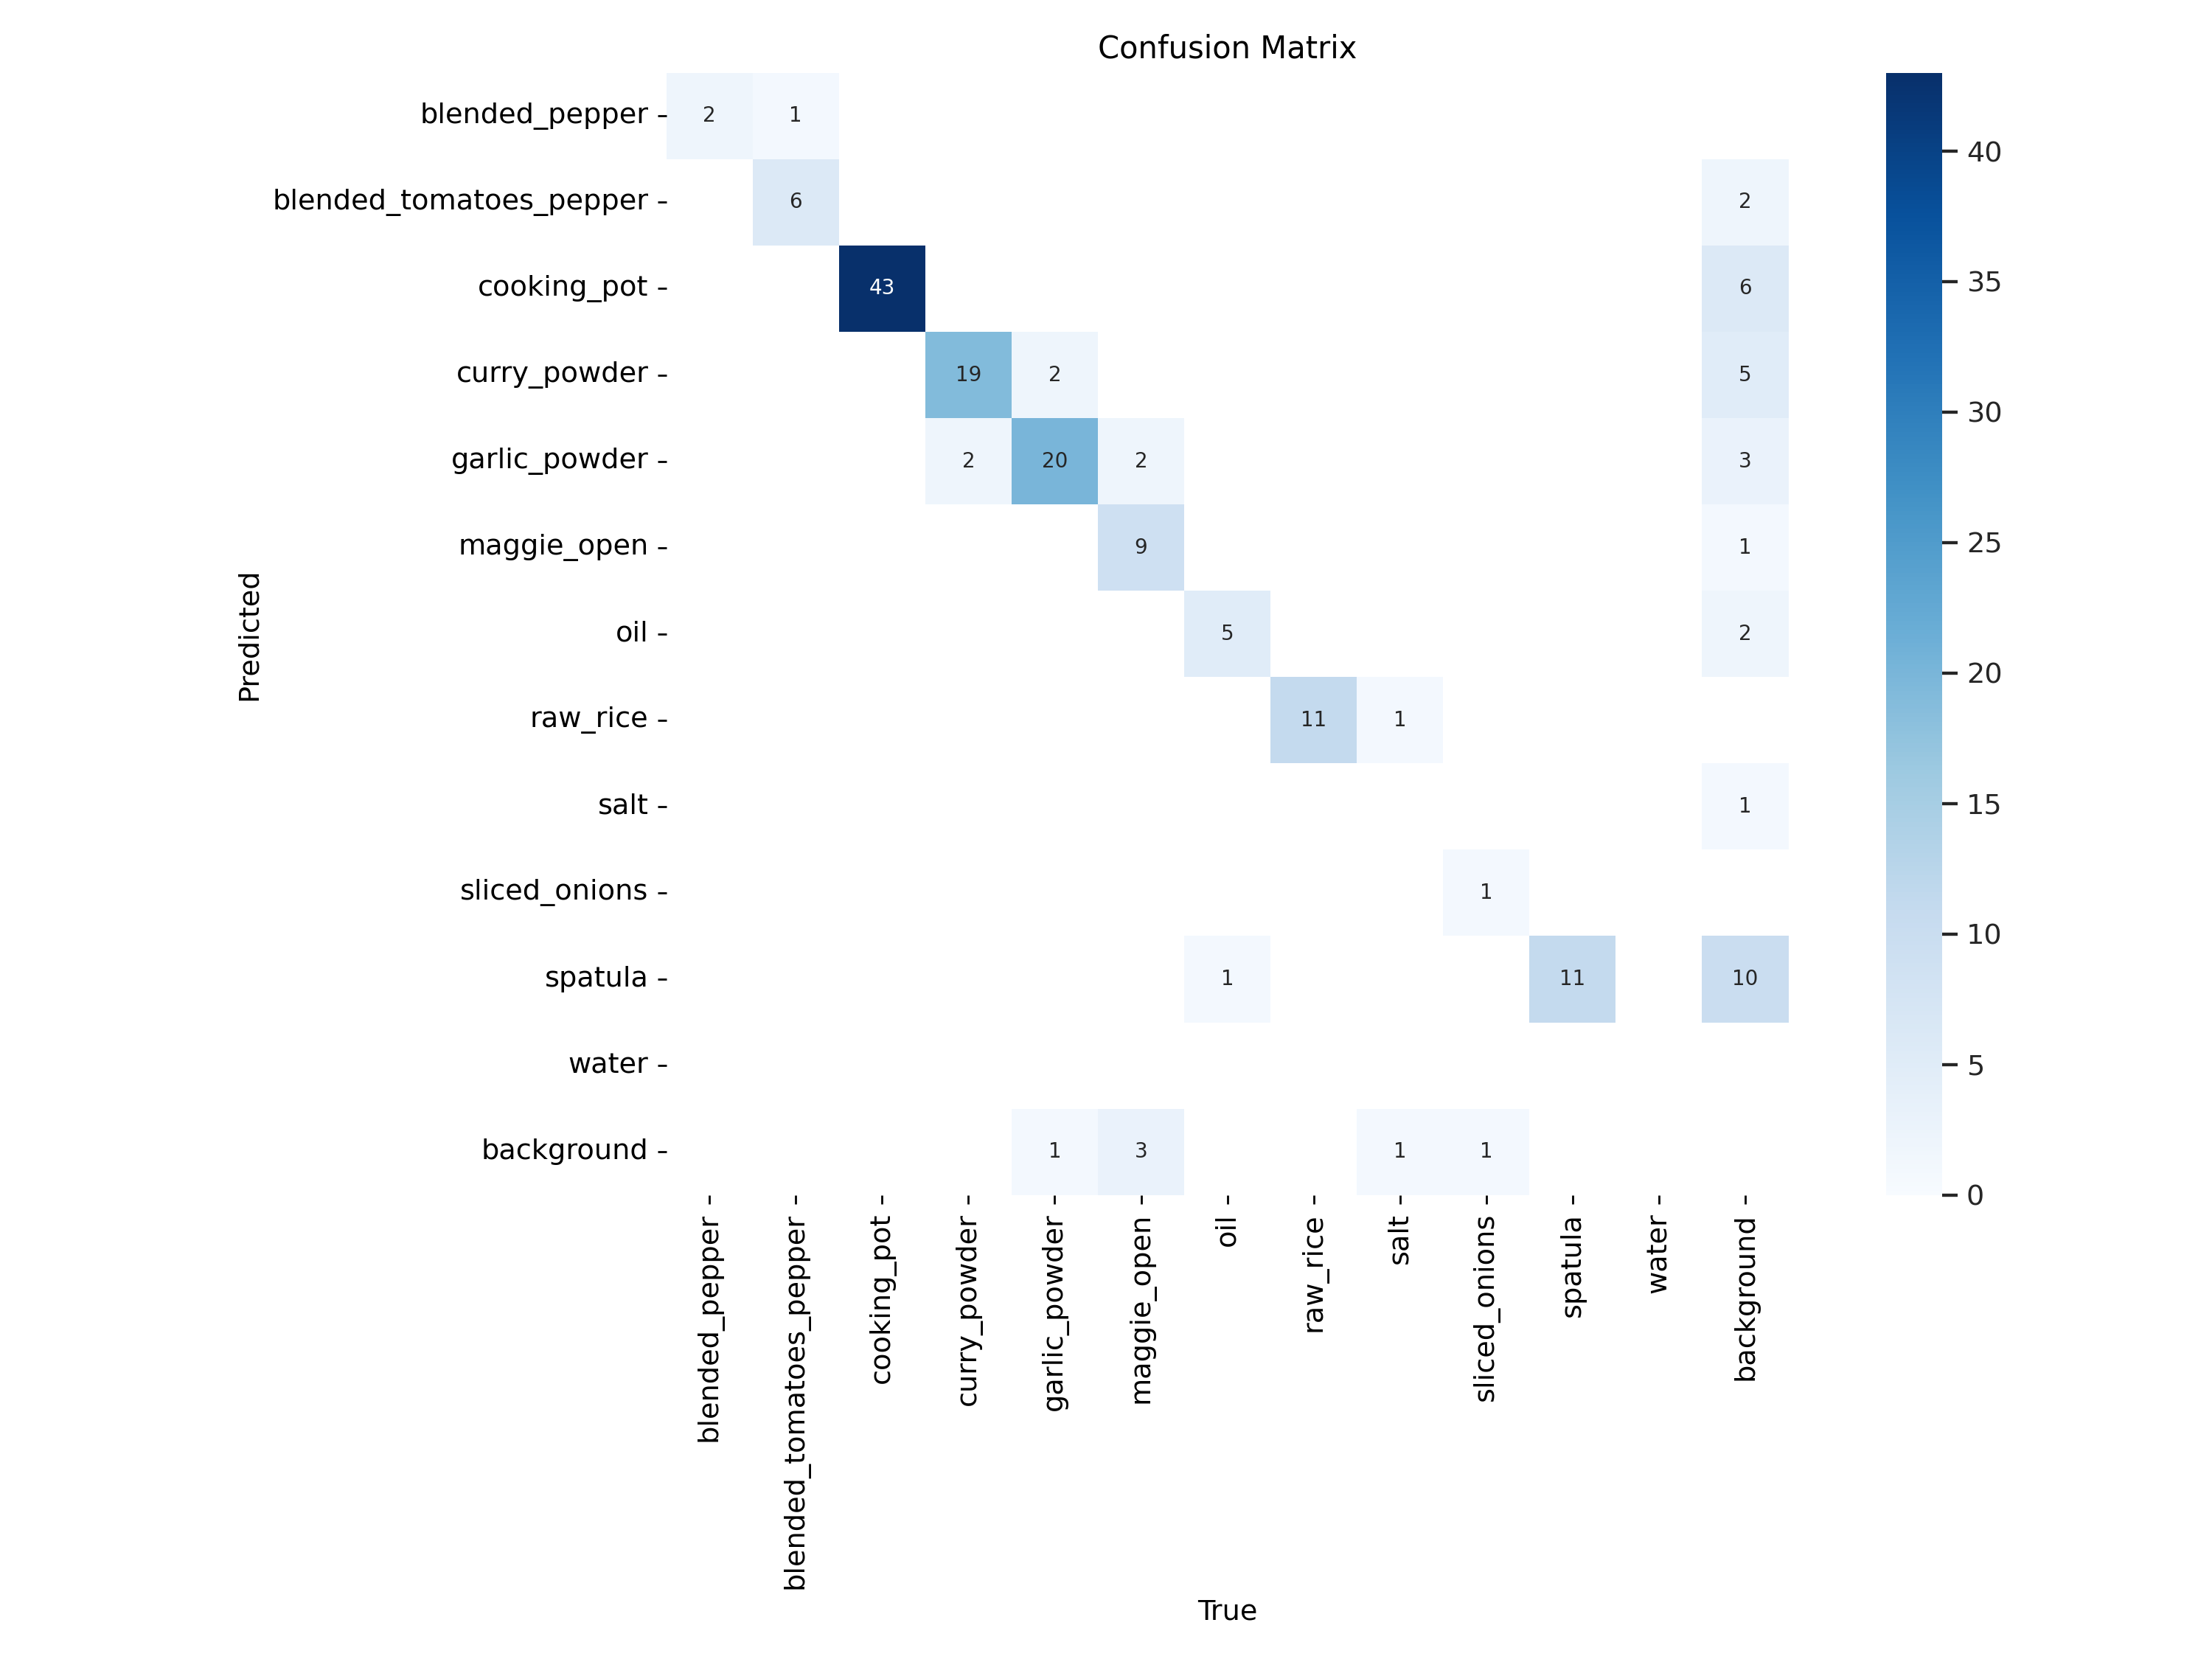

In [7]:
Image(filename=f'/content/runs/detect/train2/confusion_matrix.png', width=600)

In [8]:
!yolo task=detect mode=val model=/content/runs/detect/train2/weights/best.pt data={dataset.location}/data.yaml

Ultralytics 8.3.126 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,846,708 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1198.1±416.9 MB/s, size: 34.8 KB)
val: Scanning /content/Cooking_Jollof_Rice-1/valid/labels.cache... 68 images, 0 backgrounds, 0 corrupt: 100% 68/68 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 5/5 [00:03<00:00,  1.54it/s]
                   all         68        142      0.792      0.868      0.838       0.56
        blended_pepper          2          2      0.633          1      0.663      0.464
blended_tomatoes_pepper          7          7      0.787      0.857      0.878      0.597
           cooking_pot         41         43      0.857      0.978       0.97      0.778
          curry_powder         21         21       0.77      0.952      0.955      0.639
         garlic_powder         23         23     

In [9]:
!yolo task=detect mode=predict model=/content/runs/detect/train2/weights/best.pt source={dataset.location}/test/images save=True

Ultralytics 8.3.126 🚀 Python-3.11.12 torch-2.6.0+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 92 layers, 25,846,708 parameters, 0 gradients, 78.7 GFLOPs

image 1/34 /content/Cooking_Jollof_Rice-1/test/images/IMG_8877_JPG.rf.ccf465ab1321ec0dd62594dcefa3a761.jpg: 640x640 1 salt, 37.1ms
image 2/34 /content/Cooking_Jollof_Rice-1/test/images/IMG_8878_JPG.rf.3b74a9d2d685b153584e60bd94a25a34.jpg: 640x640 1 raw_rice, 1 salt, 37.1ms
image 3/34 /content/Cooking_Jollof_Rice-1/test/images/IMG_8900_JPG.rf.970157749e54c603c70987408bd10f3d.jpg: 640x640 1 curry_powder, 37.0ms
image 4/34 /content/Cooking_Jollof_Rice-1/test/images/IMG_8945_JPG.rf.f6da3070f34f74ca3ebb0a3b1b0cc005.jpg: 640x640 1 oil, 37.0ms
image 5/34 /content/Cooking_Jollof_Rice-1/test/images/IMG_8971-1-_JPG.rf.51fa12bdca7ccd46b90d9fb50a6b2e89.jpg: 640x640 1 blended_pepper, 1 garlic_powder, 30.1ms
image 6/34 /content/Cooking_Jollof_Rice-1/test/images/Powdered-Garlic_frame000150_jpg.rf.0ed6bda6257c0cefb557edd6dfe7b85f.jpg: 640

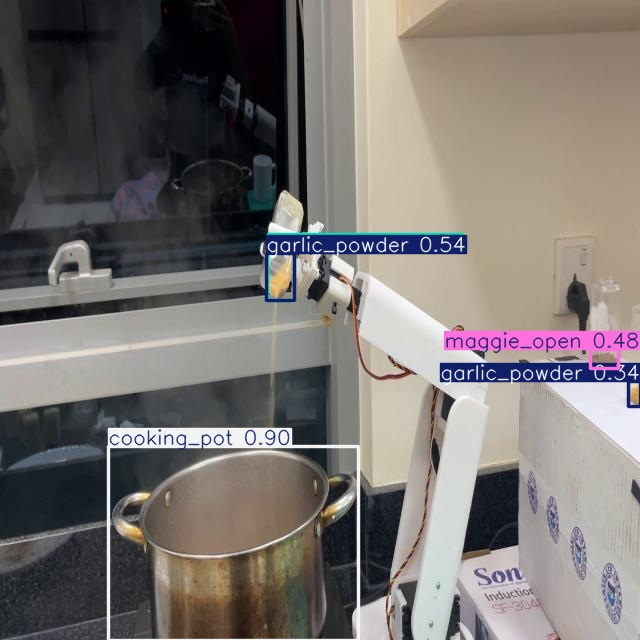

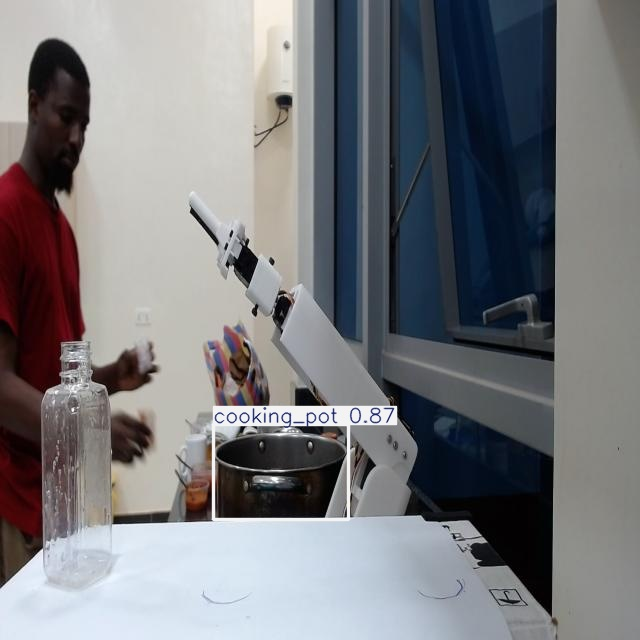

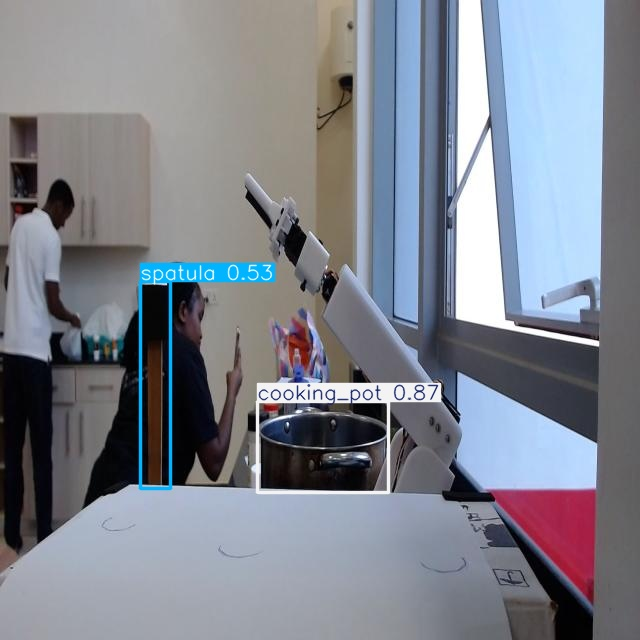

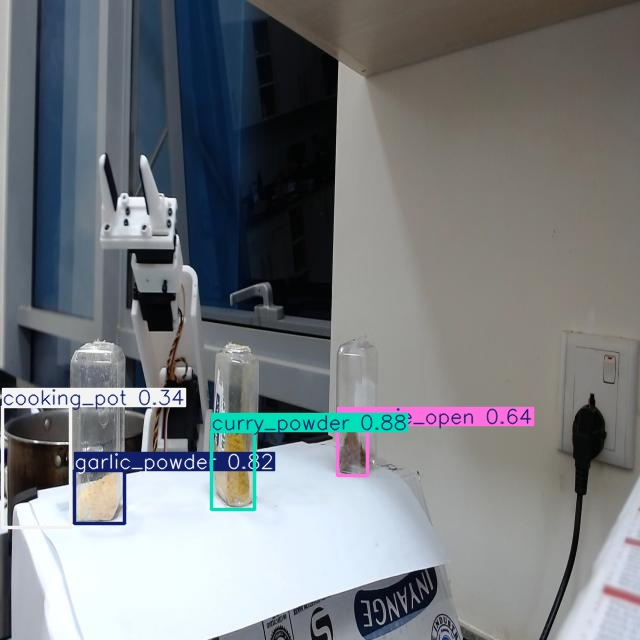

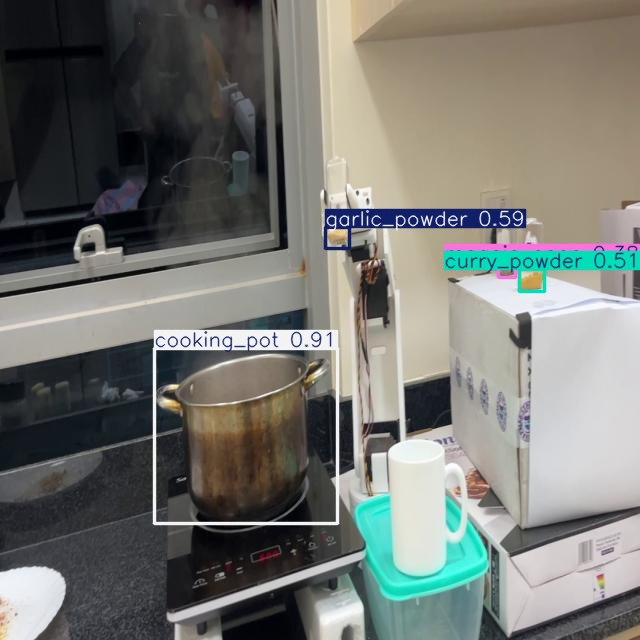

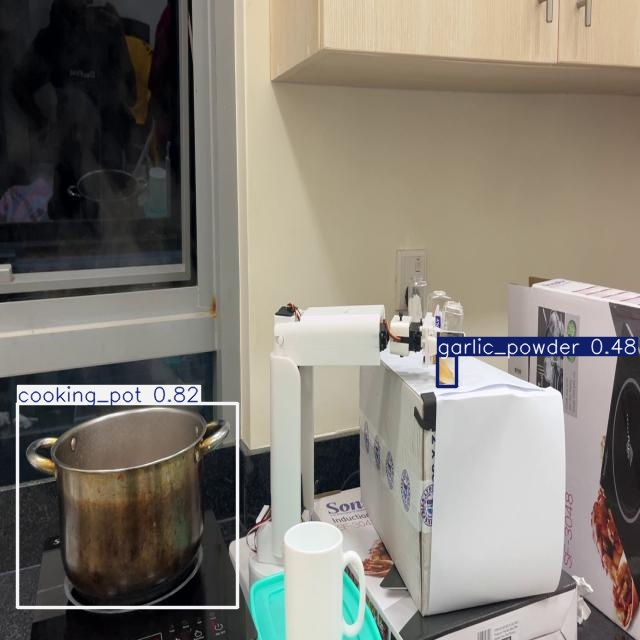

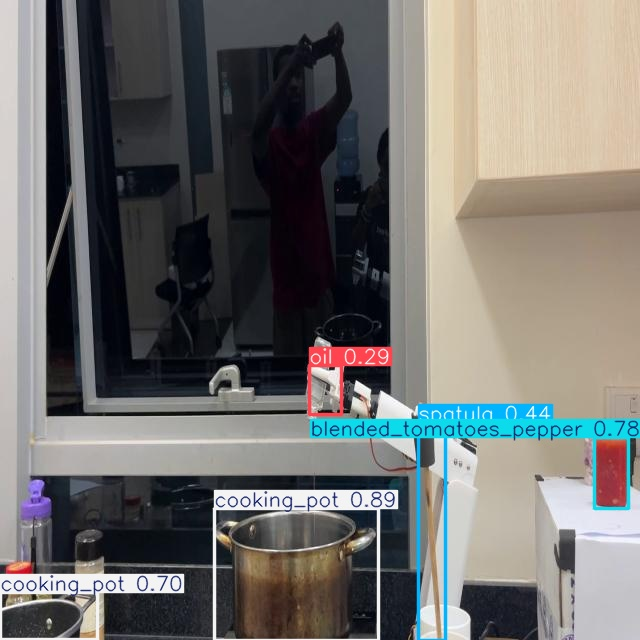

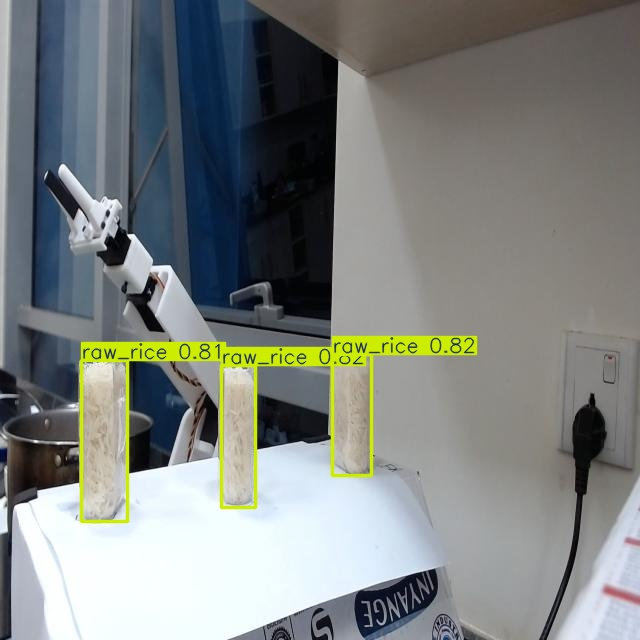

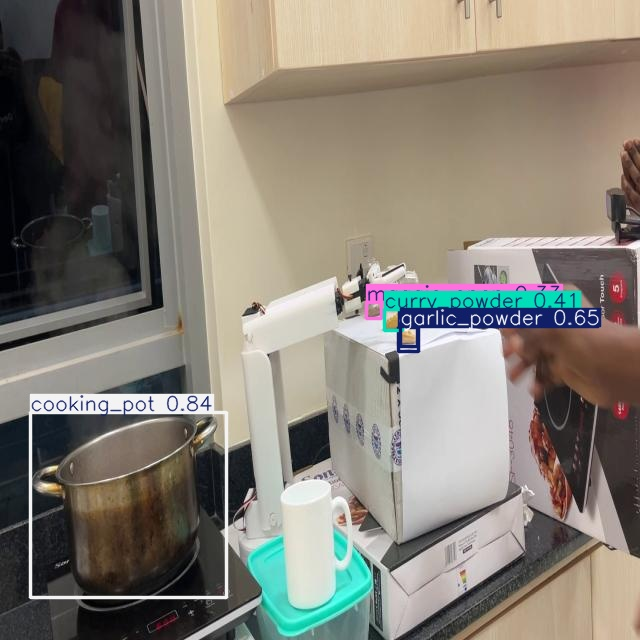

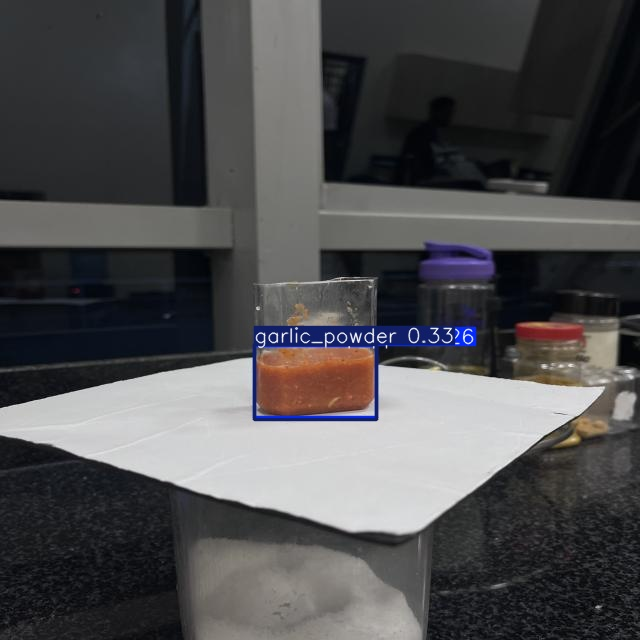

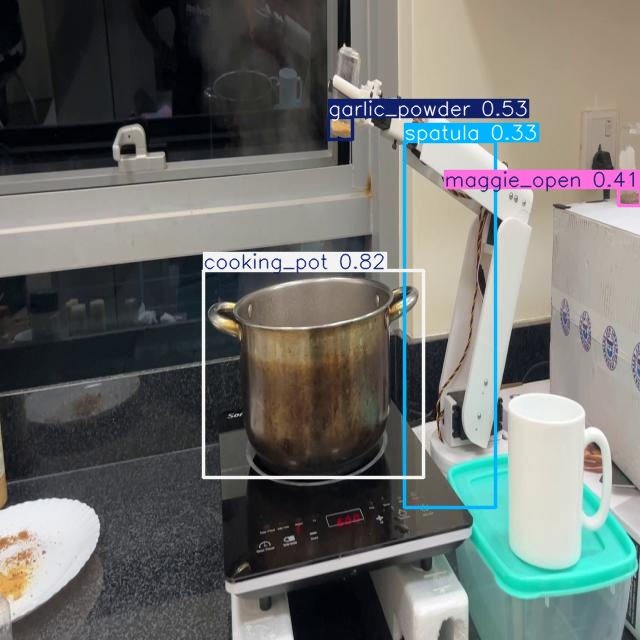

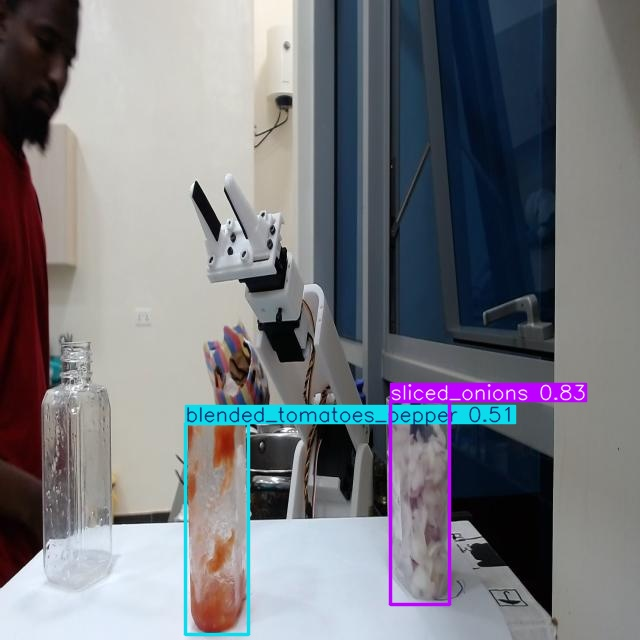

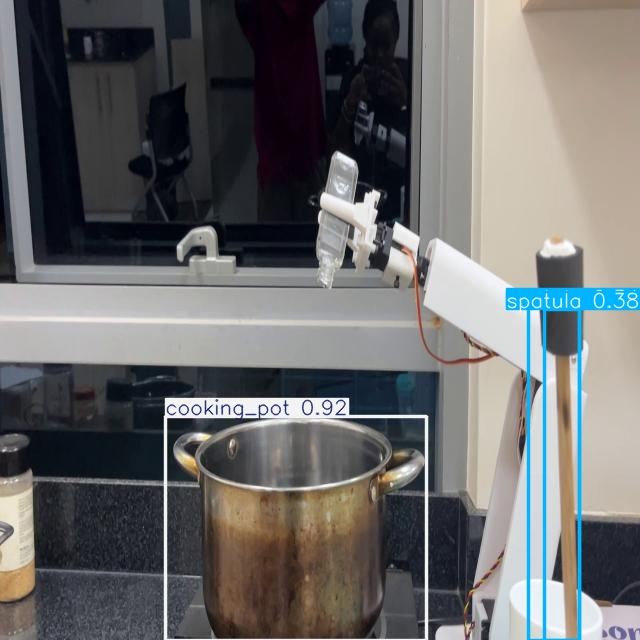

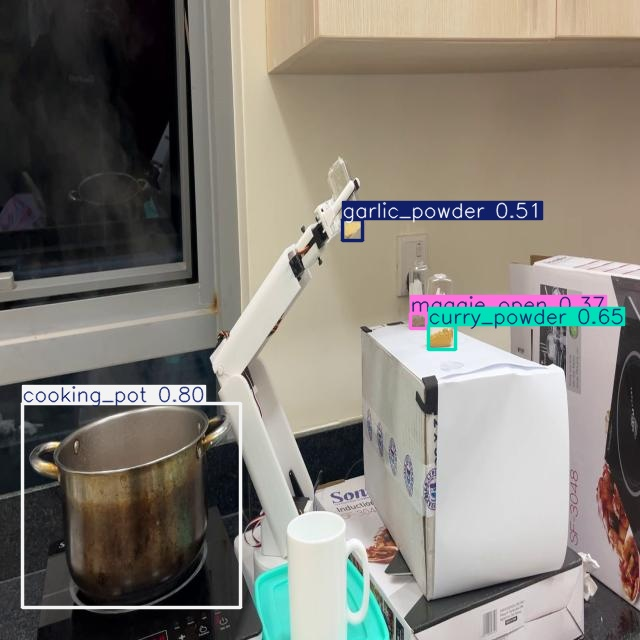

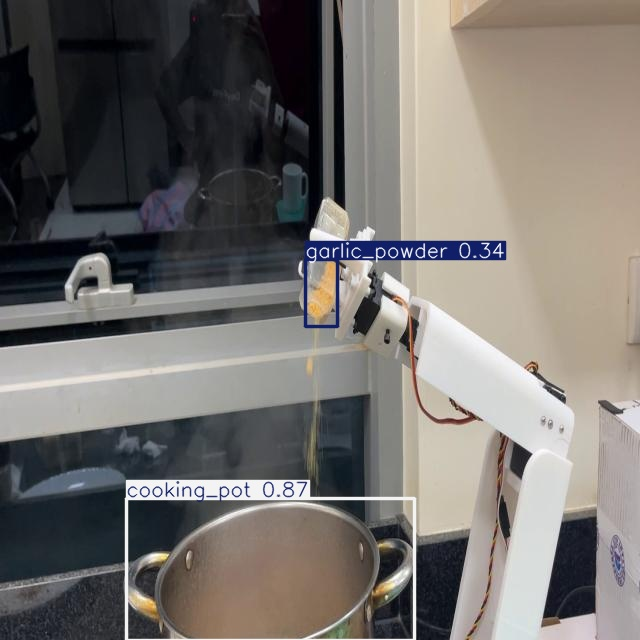

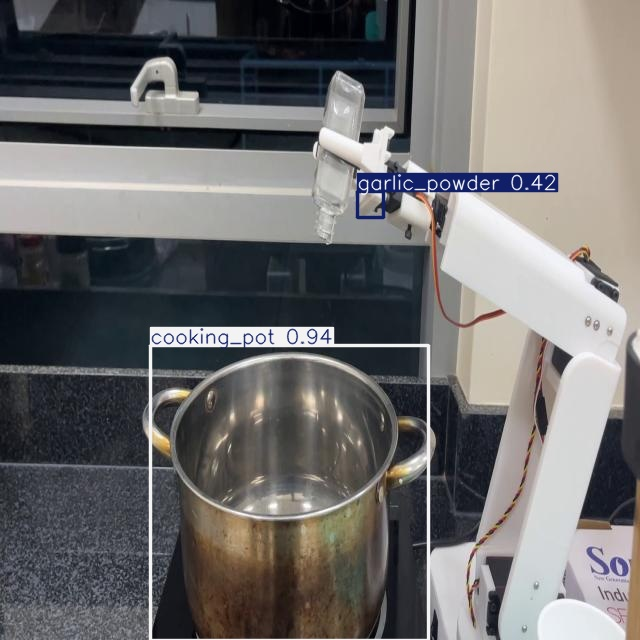

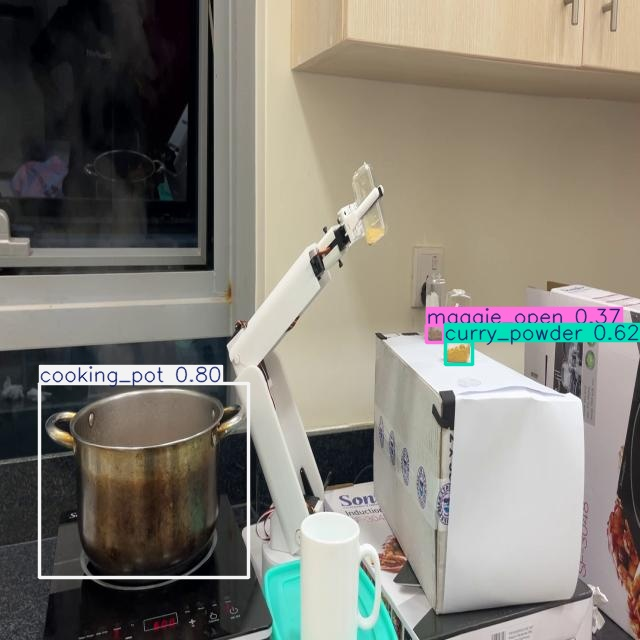

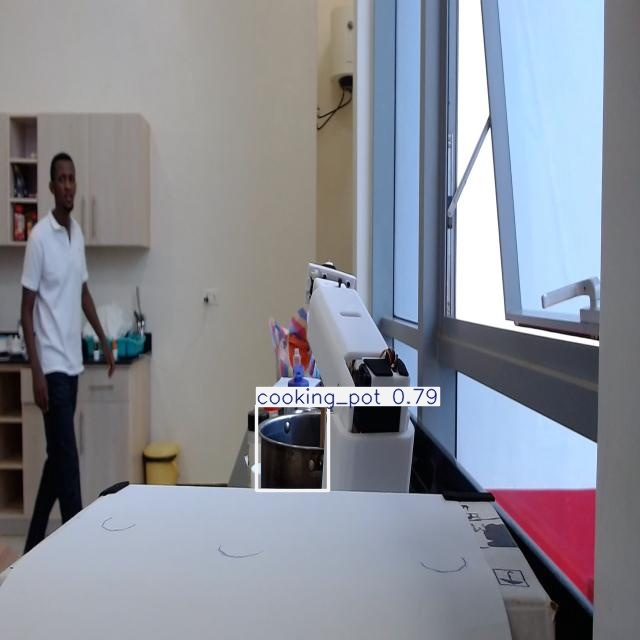

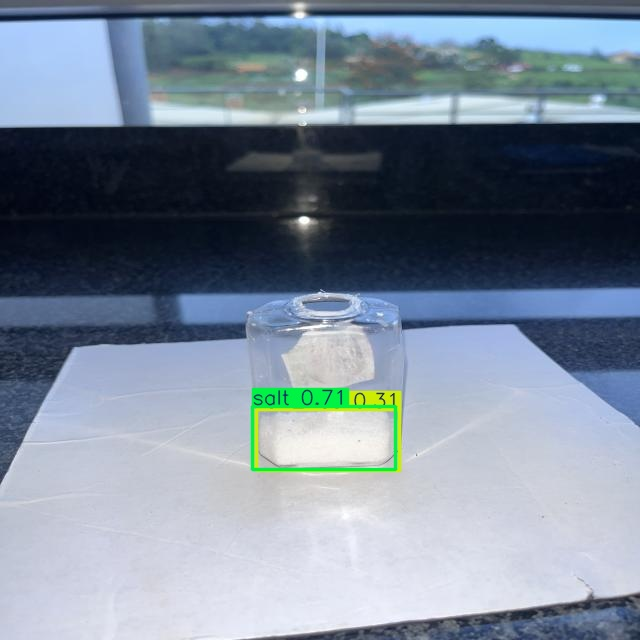

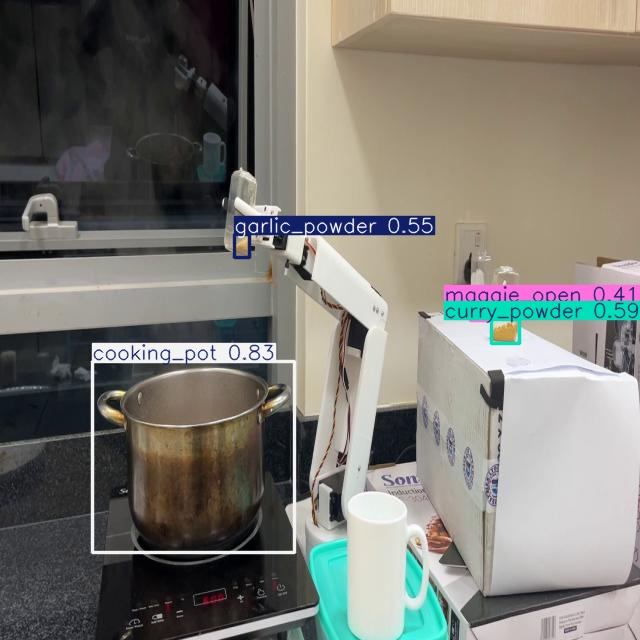

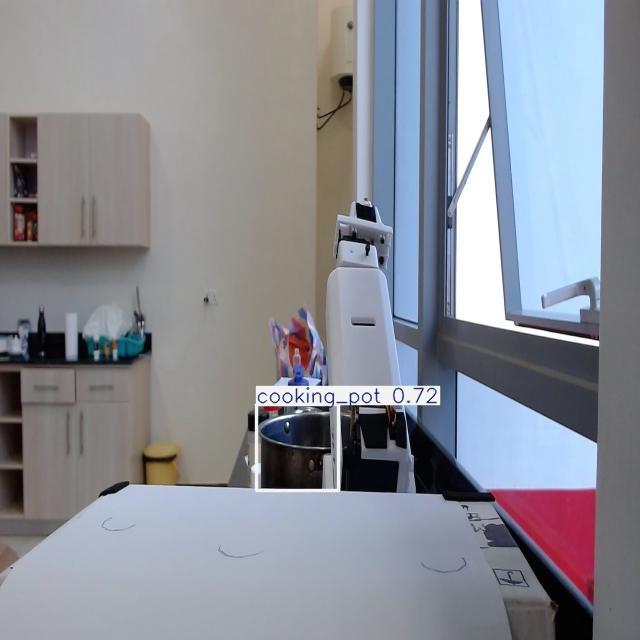

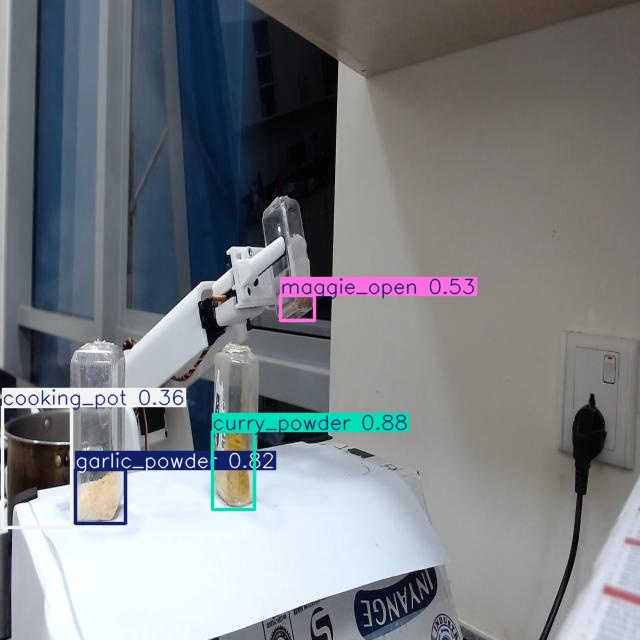

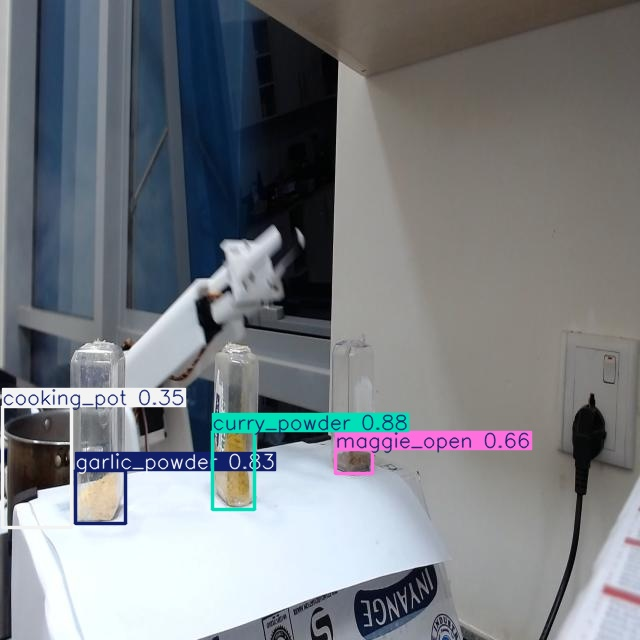

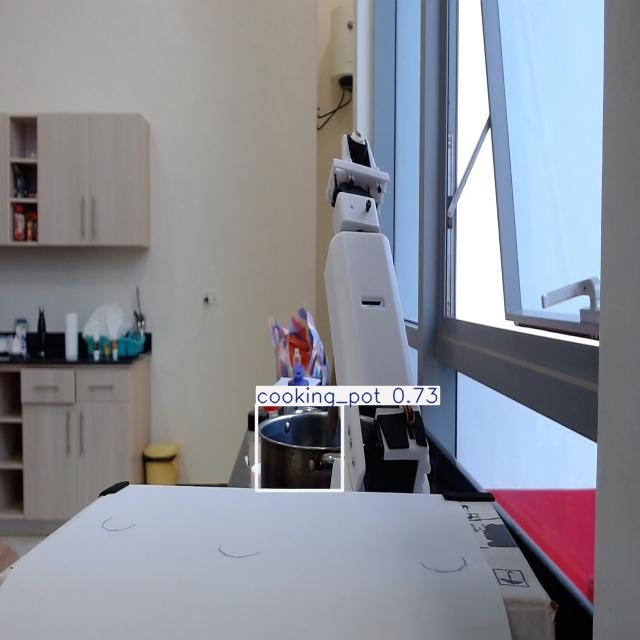

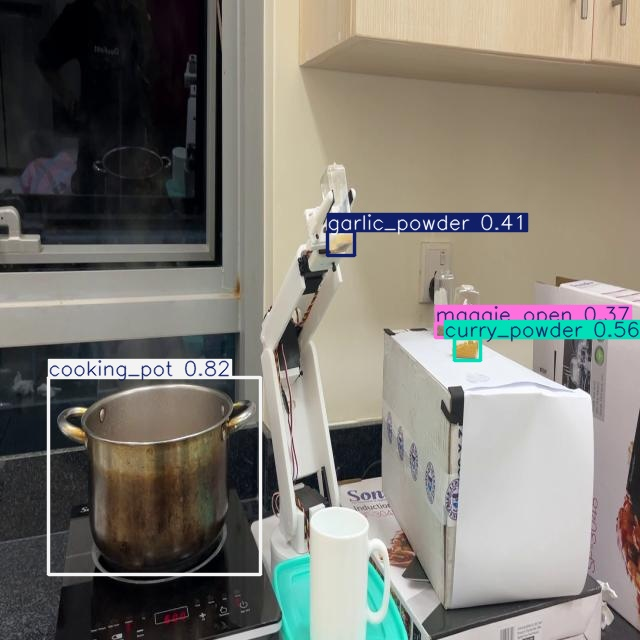

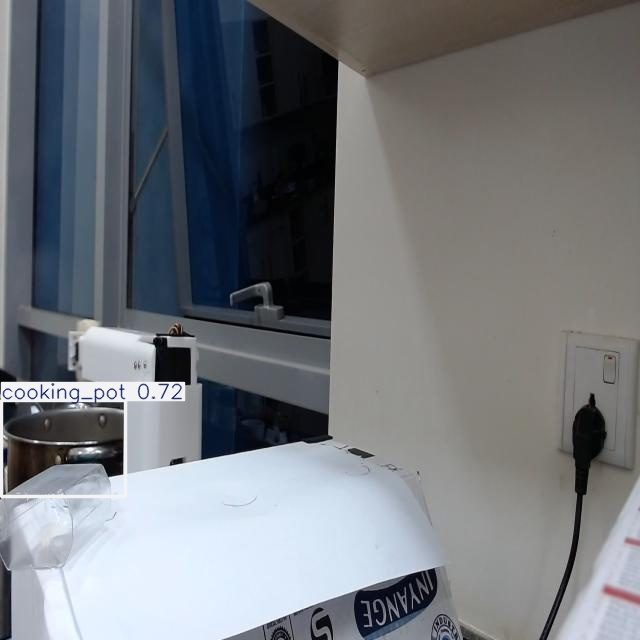

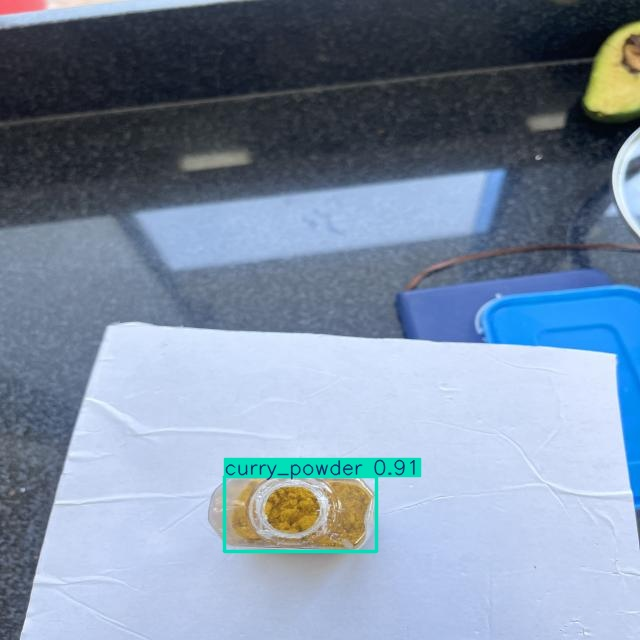

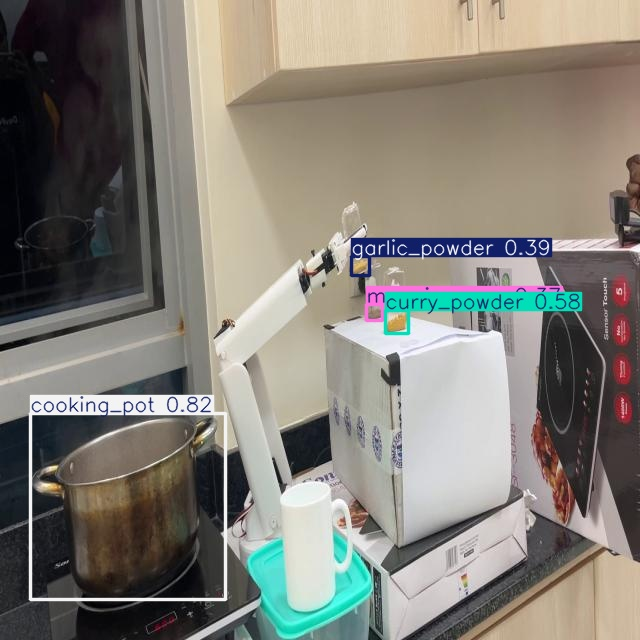

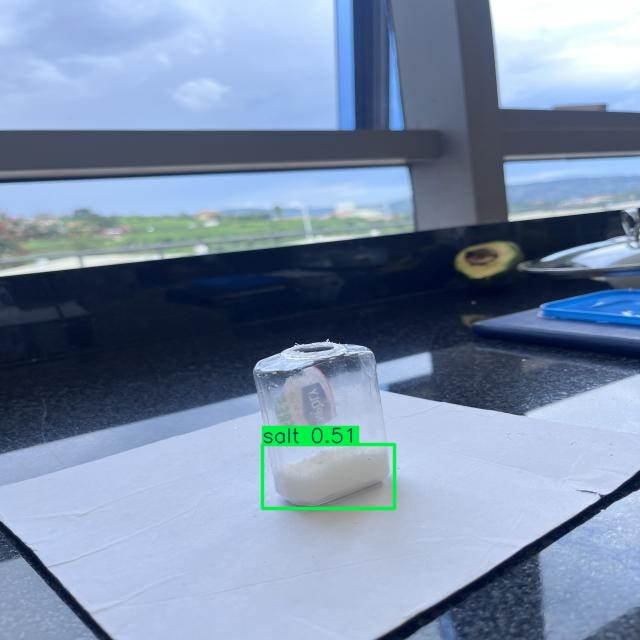

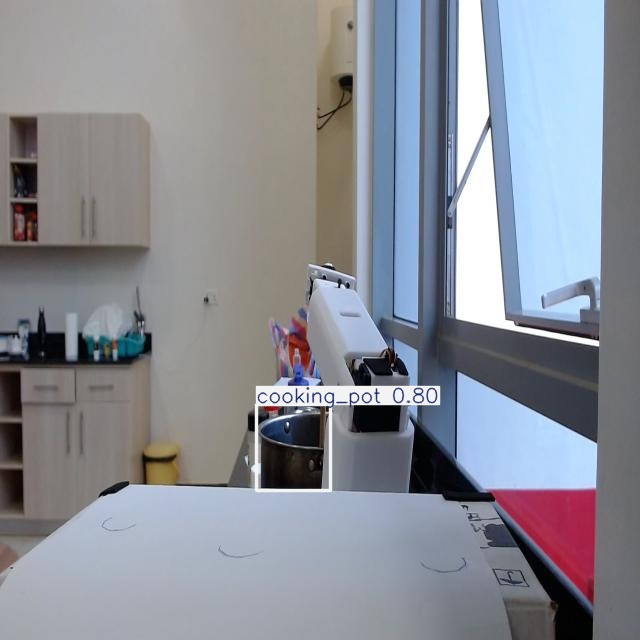

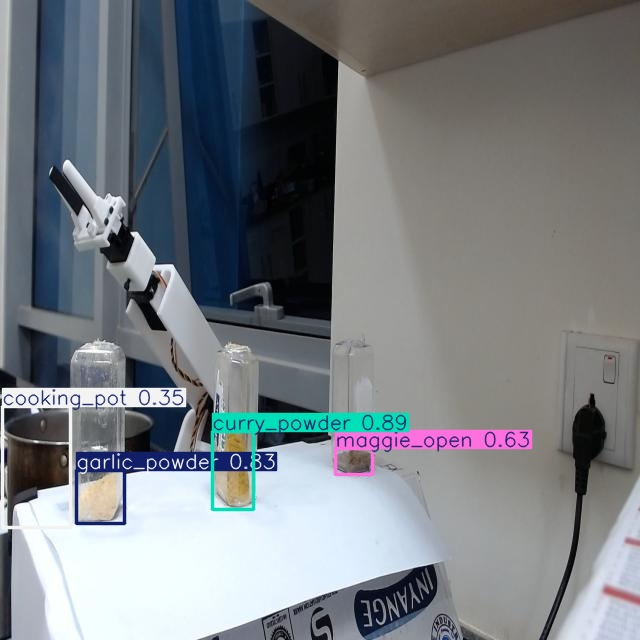

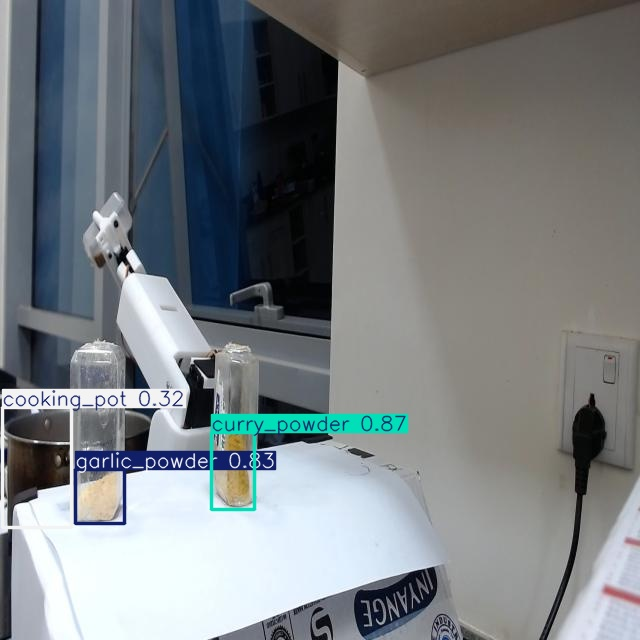

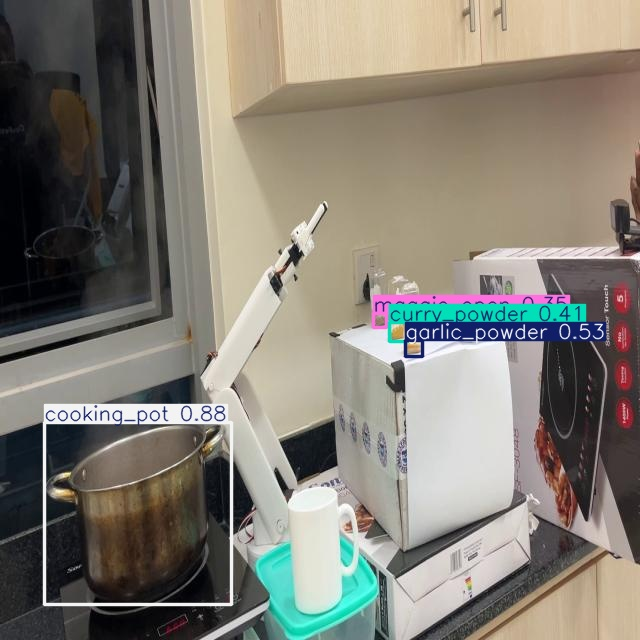

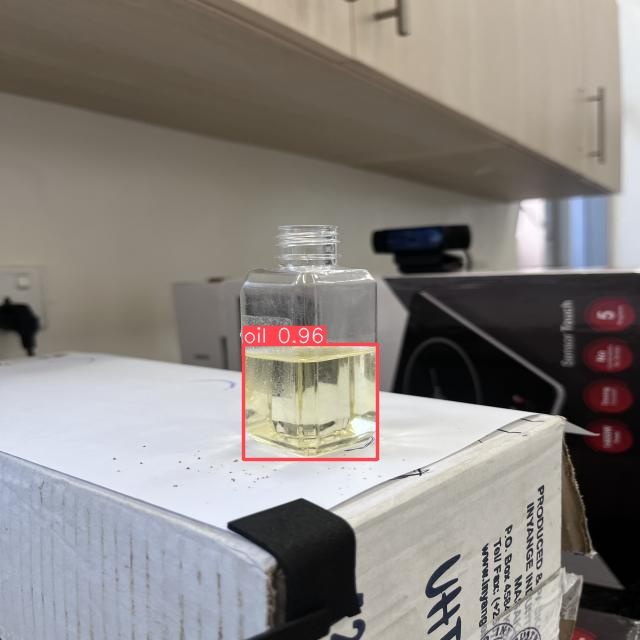

In [10]:
import glob
from IPython.display import Image, display

for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg'):
  display(Image(filename=image_path, width=600))
  print("\n")